In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("titanic.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
#Correlation between variables
#corr = df.corr()
#corr.Survived.sort_values(ascending=False).head(10)

In [10]:
df["Embarked"].unique()

<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [11]:
df["Embarked"] = df["Embarked"].replace("S",0)
df["Embarked"] = df["Embarked"].replace("C",1)
df["Embarked"] = df["Embarked"].replace("Q",2)


In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0


In [13]:
df["Sex"].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

In [14]:
df["Sex"] = df["Sex"].replace("male",0)
df["Sex"] = df["Sex"].replace("female",1)

In [15]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0


In [16]:
df["Age"].fillna(df["Age"].median(),inplace=True)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [17]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

0      0
1      1
2      0
3      0
4      0
      ..
886    0
887    0
888    0
889    1
890    2
Name: Embarked, Length: 891, dtype: object

In [18]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [19]:
df.drop("PassengerId",axis=1,inplace=True)    #,Name ,Ticket ,


In [20]:
df.drop("Name",axis=1,inplace=True) 

In [21]:
df.drop("Ticket",axis=1,inplace=True) 

In [22]:
df.drop("Cabin",axis=1,inplace=True) 

In [23]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [24]:
df.duplicated().sum()

111

In [25]:
df.drop_duplicates(inplace=True)

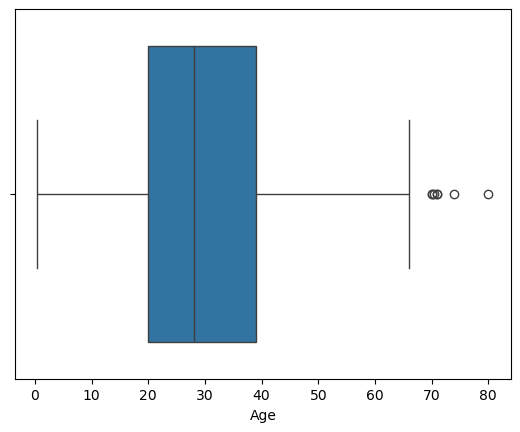

In [26]:
sns.boxplot(x=df["Age"])
plt.show()

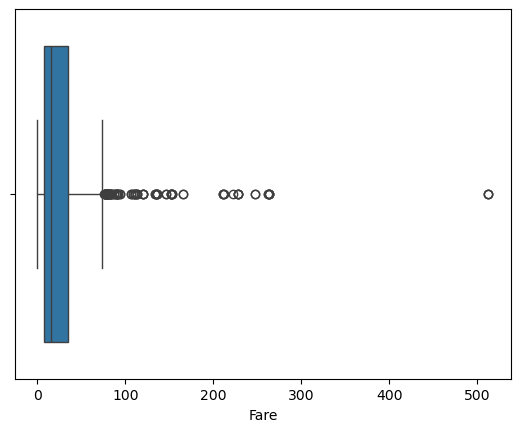

In [27]:
sns.boxplot(x=df["Fare"])
plt.show()

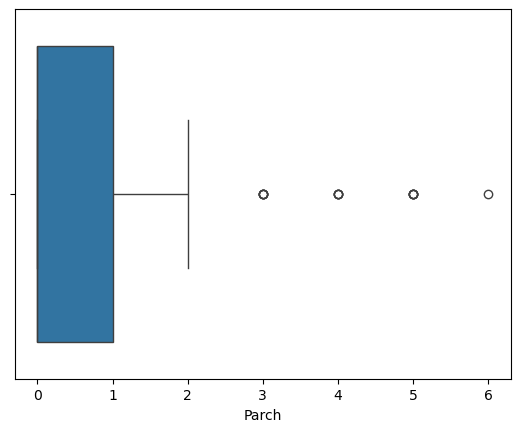

In [28]:
sns.boxplot(x=df["Parch"])
plt.show()

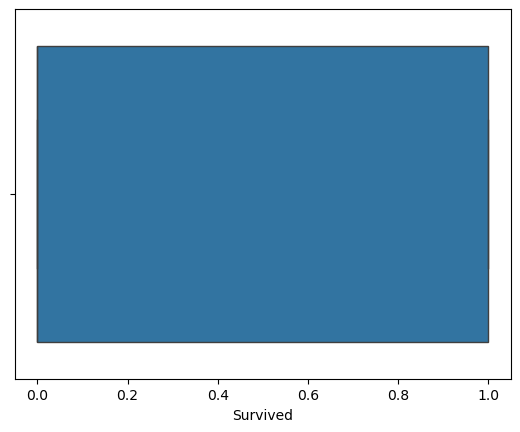

In [29]:
sns.boxplot(x=df["Survived"])
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

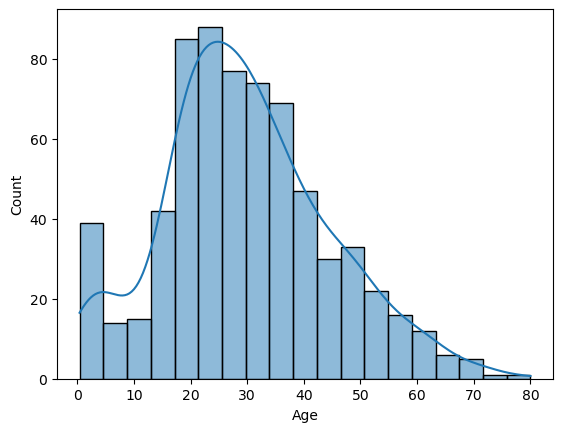

In [30]:
sns.histplot(df["Age"],kde=True)
plt.show

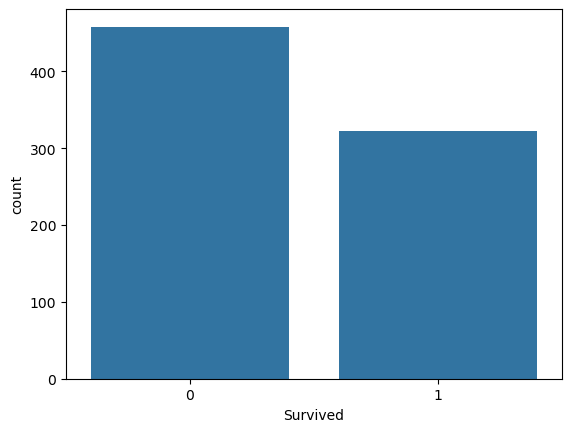

In [31]:
sns.countplot(x="Survived",data=df)
plt.show()

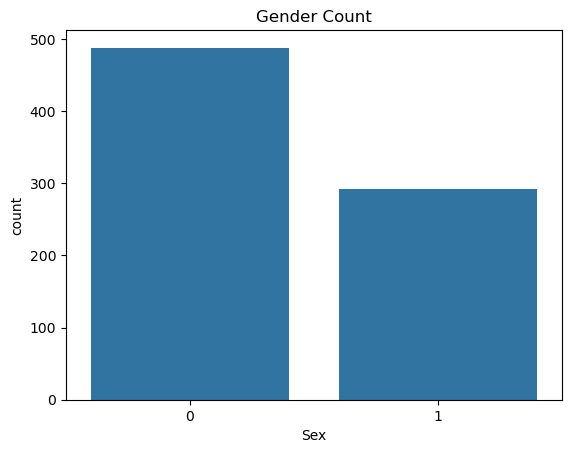

In [47]:
sns.countplot(x="Sex",data=df)
plt.title("Gender Count")
plt.show()

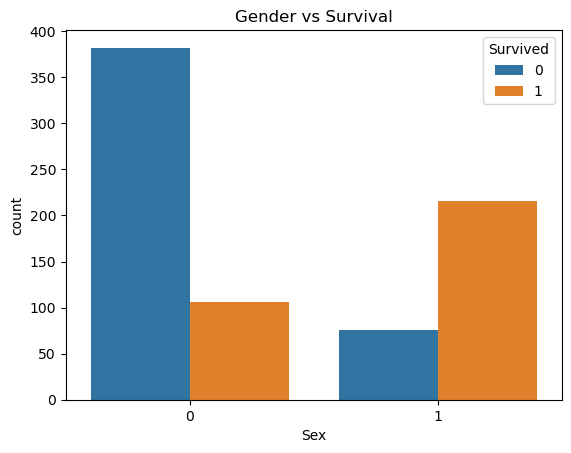

In [50]:
sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Gender vs Survival")
plt.show()

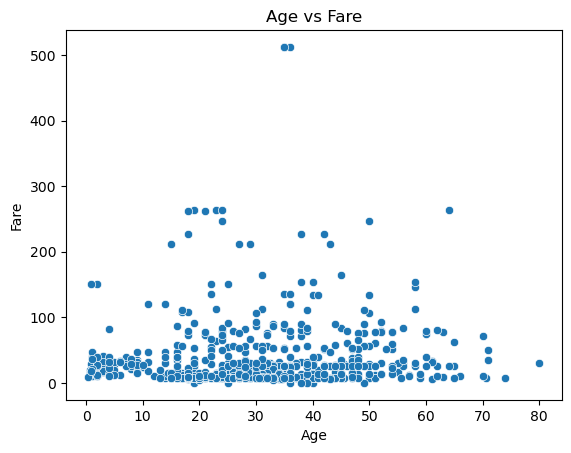

In [49]:
sns.scatterplot(x="Age",y="Fare",data=df)
plt.title("Age vs Fare")
plt.show()

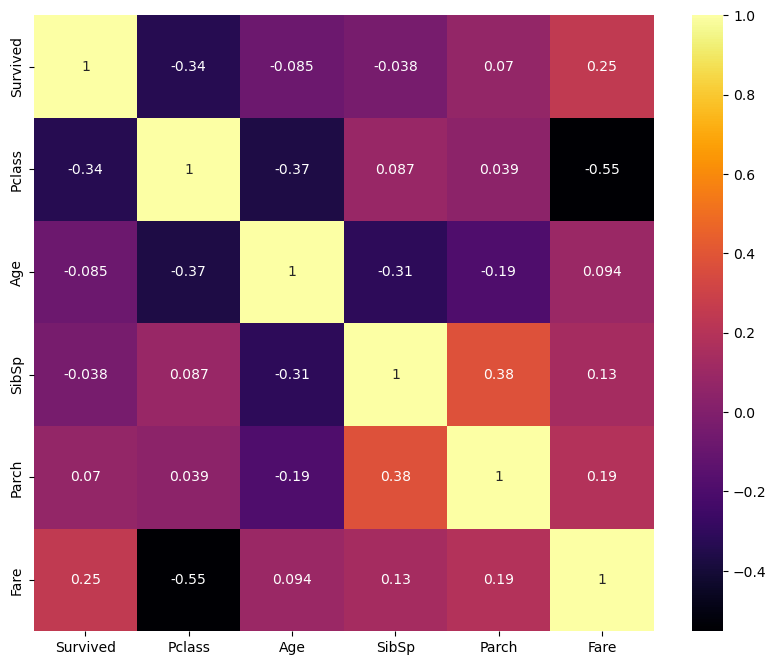

In [35]:
plt.figure(figsize=(10,8))

numeric_df =df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='inferno')
plt.show()

#viridis, plasmo ,inferno, magma ,cividis

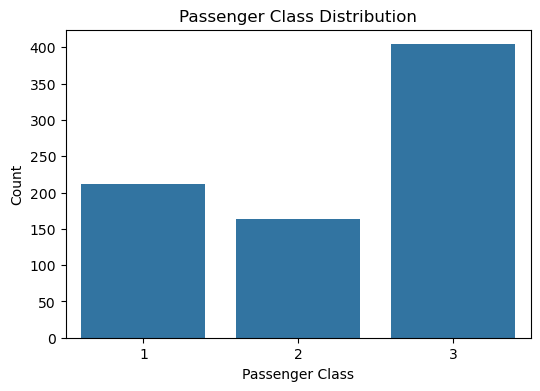

In [36]:
#Count Plot (Categorial Data)
plt.figure(figsize=(6,4))

sns.countplot(x="Pclass",data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

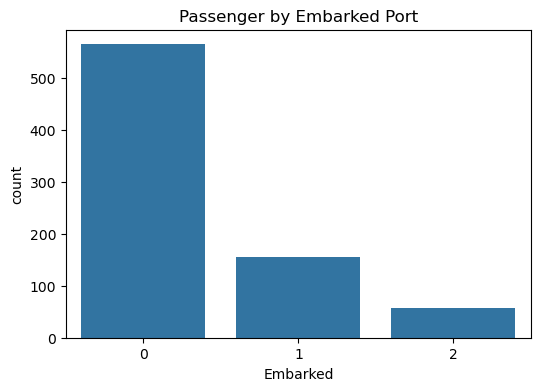

In [37]:
#Count Plot (Categorial Data)
plt.figure(figsize=(6,4))

sns.countplot(x="Embarked",data=df)

plt.title("Passenger by Embarked Port")

plt.show()

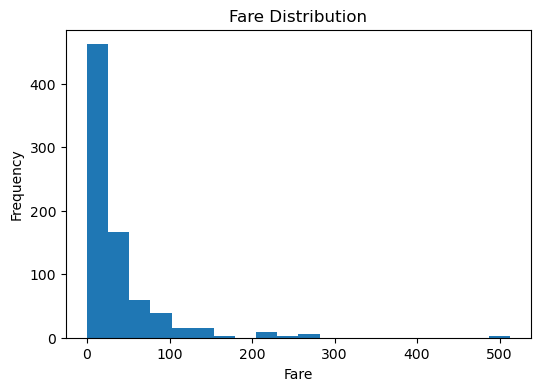

In [38]:
#Histogram
plt.figure(figsize=(6,4))
plt.hist(df["Fare"],bins=20)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()


In [39]:
#Feature Scaling
X = df.drop("Survived",axis=1)
y=df["Survived"]

In [54]:
#X=X.drop(["PassengerId","Name","Ticket"],axis=1)

In [55]:
#Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X[["Age","Fare"]] = scaler.fit_transform(X[["Age","Fare"]])

In [56]:
X.head(15)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,-0.530895,1,0,-0.528033,0
1,1,1,0.556343,1,0,0.697956,1
2,3,1,-0.259085,0,0,-0.515109,0
3,1,1,0.352486,1,0,0.349817,0
4,3,0,0.352486,0,0,-0.512716,0
5,3,0,NaN,0,0,-0.504898,2
6,1,0,1.643580,0,0,0.326123,0
7,3,0,-1.889941,3,1,-0.263338,0
8,3,1,-0.191133,0,2,-0.453683,0
9,2,1,-1.074513,1,0,-0.091103,1


In [57]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state = 42)

In [58]:
print("Training Data :" ,X_train.shape)
print("Testing Data :" ,X_test.shape)


Training Data : (624, 7)
Testing Data : (156, 7)


In [59]:
print(X_train.head())

     Pclass Sex       Age  SibSp  Parch      Fare Embarked
789       1   0  1.099961      0      0  0.849530        1
722       2   0  0.284533      0      0 -0.417943        0
141       3   1 -0.530895      0      0 -0.518460        0
388       3   0       NaN      0      0 -0.518858        2
56        2   1 -0.598847      0      0 -0.465808        0
